In [36]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import tree, ensemble
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression

In [ ]:
#1

In [2]:
df = pd.read_csv('heart.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [ ]:
#2

In [5]:
df_le = df.copy()

cat_cols = df_le.select_dtypes(include=['object']).columns

le = LabelEncoder()
for col in cat_cols:
    df_le[col] = le.fit_transform(df_le[col])

df_le.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,1,140,289,0,1,172,0,0.0,2,0
1,49,0,2,160,180,0,1,156,0,1.0,1,1
2,37,1,1,130,283,0,2,98,0,0.0,2,0
3,48,0,0,138,214,0,1,108,1,1.5,1,1
4,54,1,2,150,195,0,1,122,0,0.0,2,0


<Figure size 800x500 with 0 Axes>

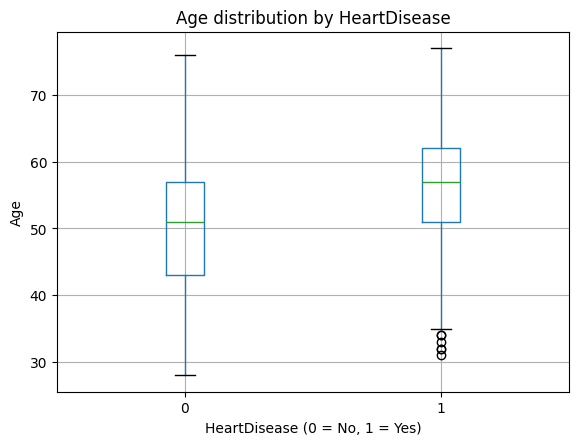

In [10]:
# Plot 1 — Age distribution depending on the presence of heart disease
plt.figure(figsize=(8,5))
df.boxplot(column='Age', by='HeartDisease')
plt.title("Age distribution by HeartDisease")
plt.suptitle("")
plt.xlabel("HeartDisease (0 = No, 1 = Yes)")
plt.ylabel("Age")
plt.show()

<Figure size 800x500 with 0 Axes>

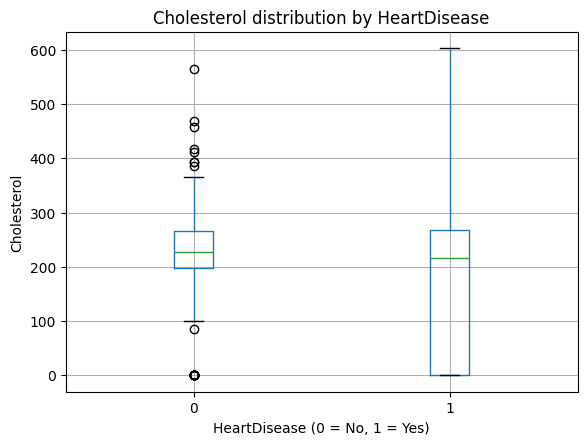

In [11]:
# Plot 2 - Cholesterol distribution by HeartDisease
plt.figure(figsize=(8,5))
df.boxplot(column='Cholesterol', by='HeartDisease')
plt.title("Cholesterol distribution by HeartDisease")
plt.suptitle("")
plt.xlabel("HeartDisease (0 = No, 1 = Yes)")
plt.ylabel("Cholesterol")
plt.show()

In [ ]:
#3

In [14]:
y = df_le['HeartDisease']

X = df_le.drop('HeartDisease', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape

((734, 11), (184, 11))

In [ ]:
#4

In [17]:
# Decision Tree
dt_model = tree.DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [18]:
# Random Forest
rf_model = ensemble.RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
#5

In [23]:
dt_pred = dt_model.predict(X_test)
print("Decision Tree Classification Report")
print(classification_report(y_test, dt_pred))

Decision Tree Classification Report
              precision    recall  f1-score   support

           0       0.70      0.83      0.76        77
           1       0.86      0.75      0.80       107

    accuracy                           0.78       184
   macro avg       0.78      0.79      0.78       184
weighted avg       0.79      0.78      0.78       184



In [24]:
rf_pred = rf_model.predict(X_test)
print("Random Forest Classification Report")
print(classification_report(y_test, rf_pred))

Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.84      0.84      0.84        77
           1       0.89      0.89      0.89       107

    accuracy                           0.87       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.87      0.87       184



In [ ]:
#6

In [25]:
importances = rf_model.feature_importances_
feature_names = X_train.columns

feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feat_imp)

           Feature  Importance
10        ST_Slope    0.241583
9          Oldpeak    0.122604
4      Cholesterol    0.107333
7            MaxHR    0.103918
8   ExerciseAngina    0.100037
2    ChestPainType    0.092719
0              Age    0.085562
3        RestingBP    0.066506
1              Sex    0.033995
6       RestingECG    0.026215
5        FastingBS    0.019527


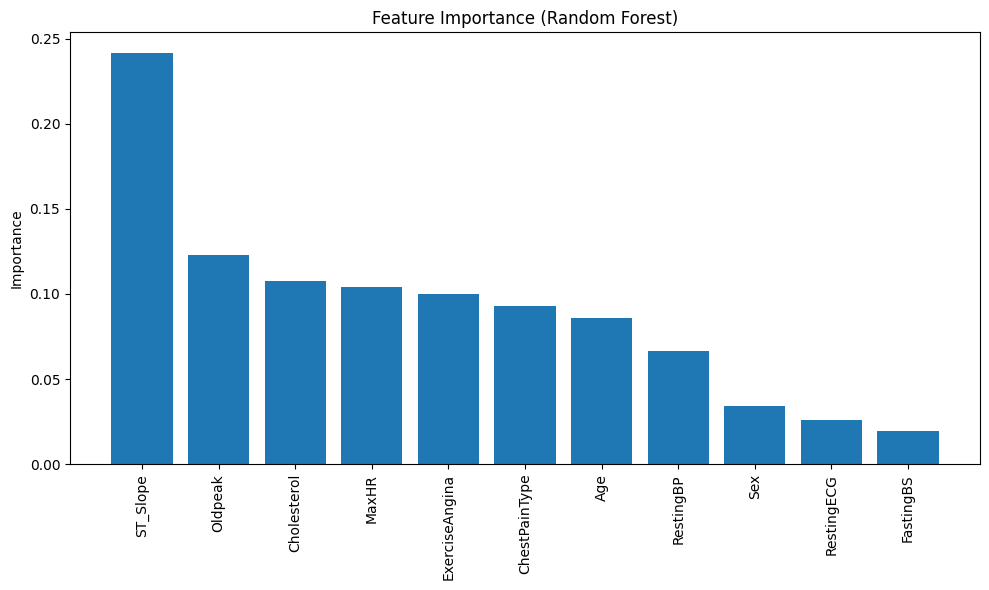

In [26]:
plt.figure(figsize=(10,6))
plt.bar(feat_imp['Feature'], feat_imp['Importance'])
plt.xticks(rotation=90)
plt.title("Feature Importance (Random Forest)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

In [ ]:
#7

In [32]:
bag_model = BaggingClassifier(
    estimator=tree.DecisionTreeClassifier(random_state=42),
    n_estimators=50,
    random_state=42
)

bag_model.fit(X_train, y_train)
bag_pred = bag_model.predict(X_test)

print("Bagging (Decision Tree) Classification Report")
print(classification_report(y_test, bag_pred))

Bagging (Decision Tree) Classification Report
              precision    recall  f1-score   support

           0       0.84      0.88      0.86        77
           1       0.91      0.88      0.90       107

    accuracy                           0.88       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.88      0.88      0.88       184



In [ ]:
#8

In [34]:
stack_estimators = [
    ('dt', tree.DecisionTreeClassifier(random_state=42)),
    ('rf', ensemble.RandomForestClassifier(random_state=42)),
    ('svc', LinearSVC(random_state=42))]

final_model = LogisticRegression(max_iter=500)

stack_model = StackingClassifier(
    estimators=stack_estimators,
    final_estimator=final_model,
    passthrough=False)

stack_model.fit(X_train, y_train)

stack_pred = stack_model.predict(X_test)

print("Stacking Classifier Report")
print(classification_report(y_test, stack_pred))

Stacking Classifier Report
              precision    recall  f1-score   support

           0       0.82      0.88      0.85        77
           1       0.91      0.86      0.88       107

    accuracy                           0.87       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.87      0.87       184



In [ ]:
#9

In [38]:
models = {
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "Bagging (DT)": bag_pred,
    "Stacking": stack_pred
}

results = []

for name, pred in models.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1-score": f1_score(y_test, pred)
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.782609,0.860215,0.747664,0.800000
1,Random Forest,0.869565,0.887850,0.887850,0.887850
2,Bagging (DT),0.880435,0.912621,0.878505,0.895238
3,Stacking,0.869565,0.910891,0.859813,0.884615
